LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.
Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.5.1_L0/imagenet_l0_semantic_vs_global_flipped.pdf


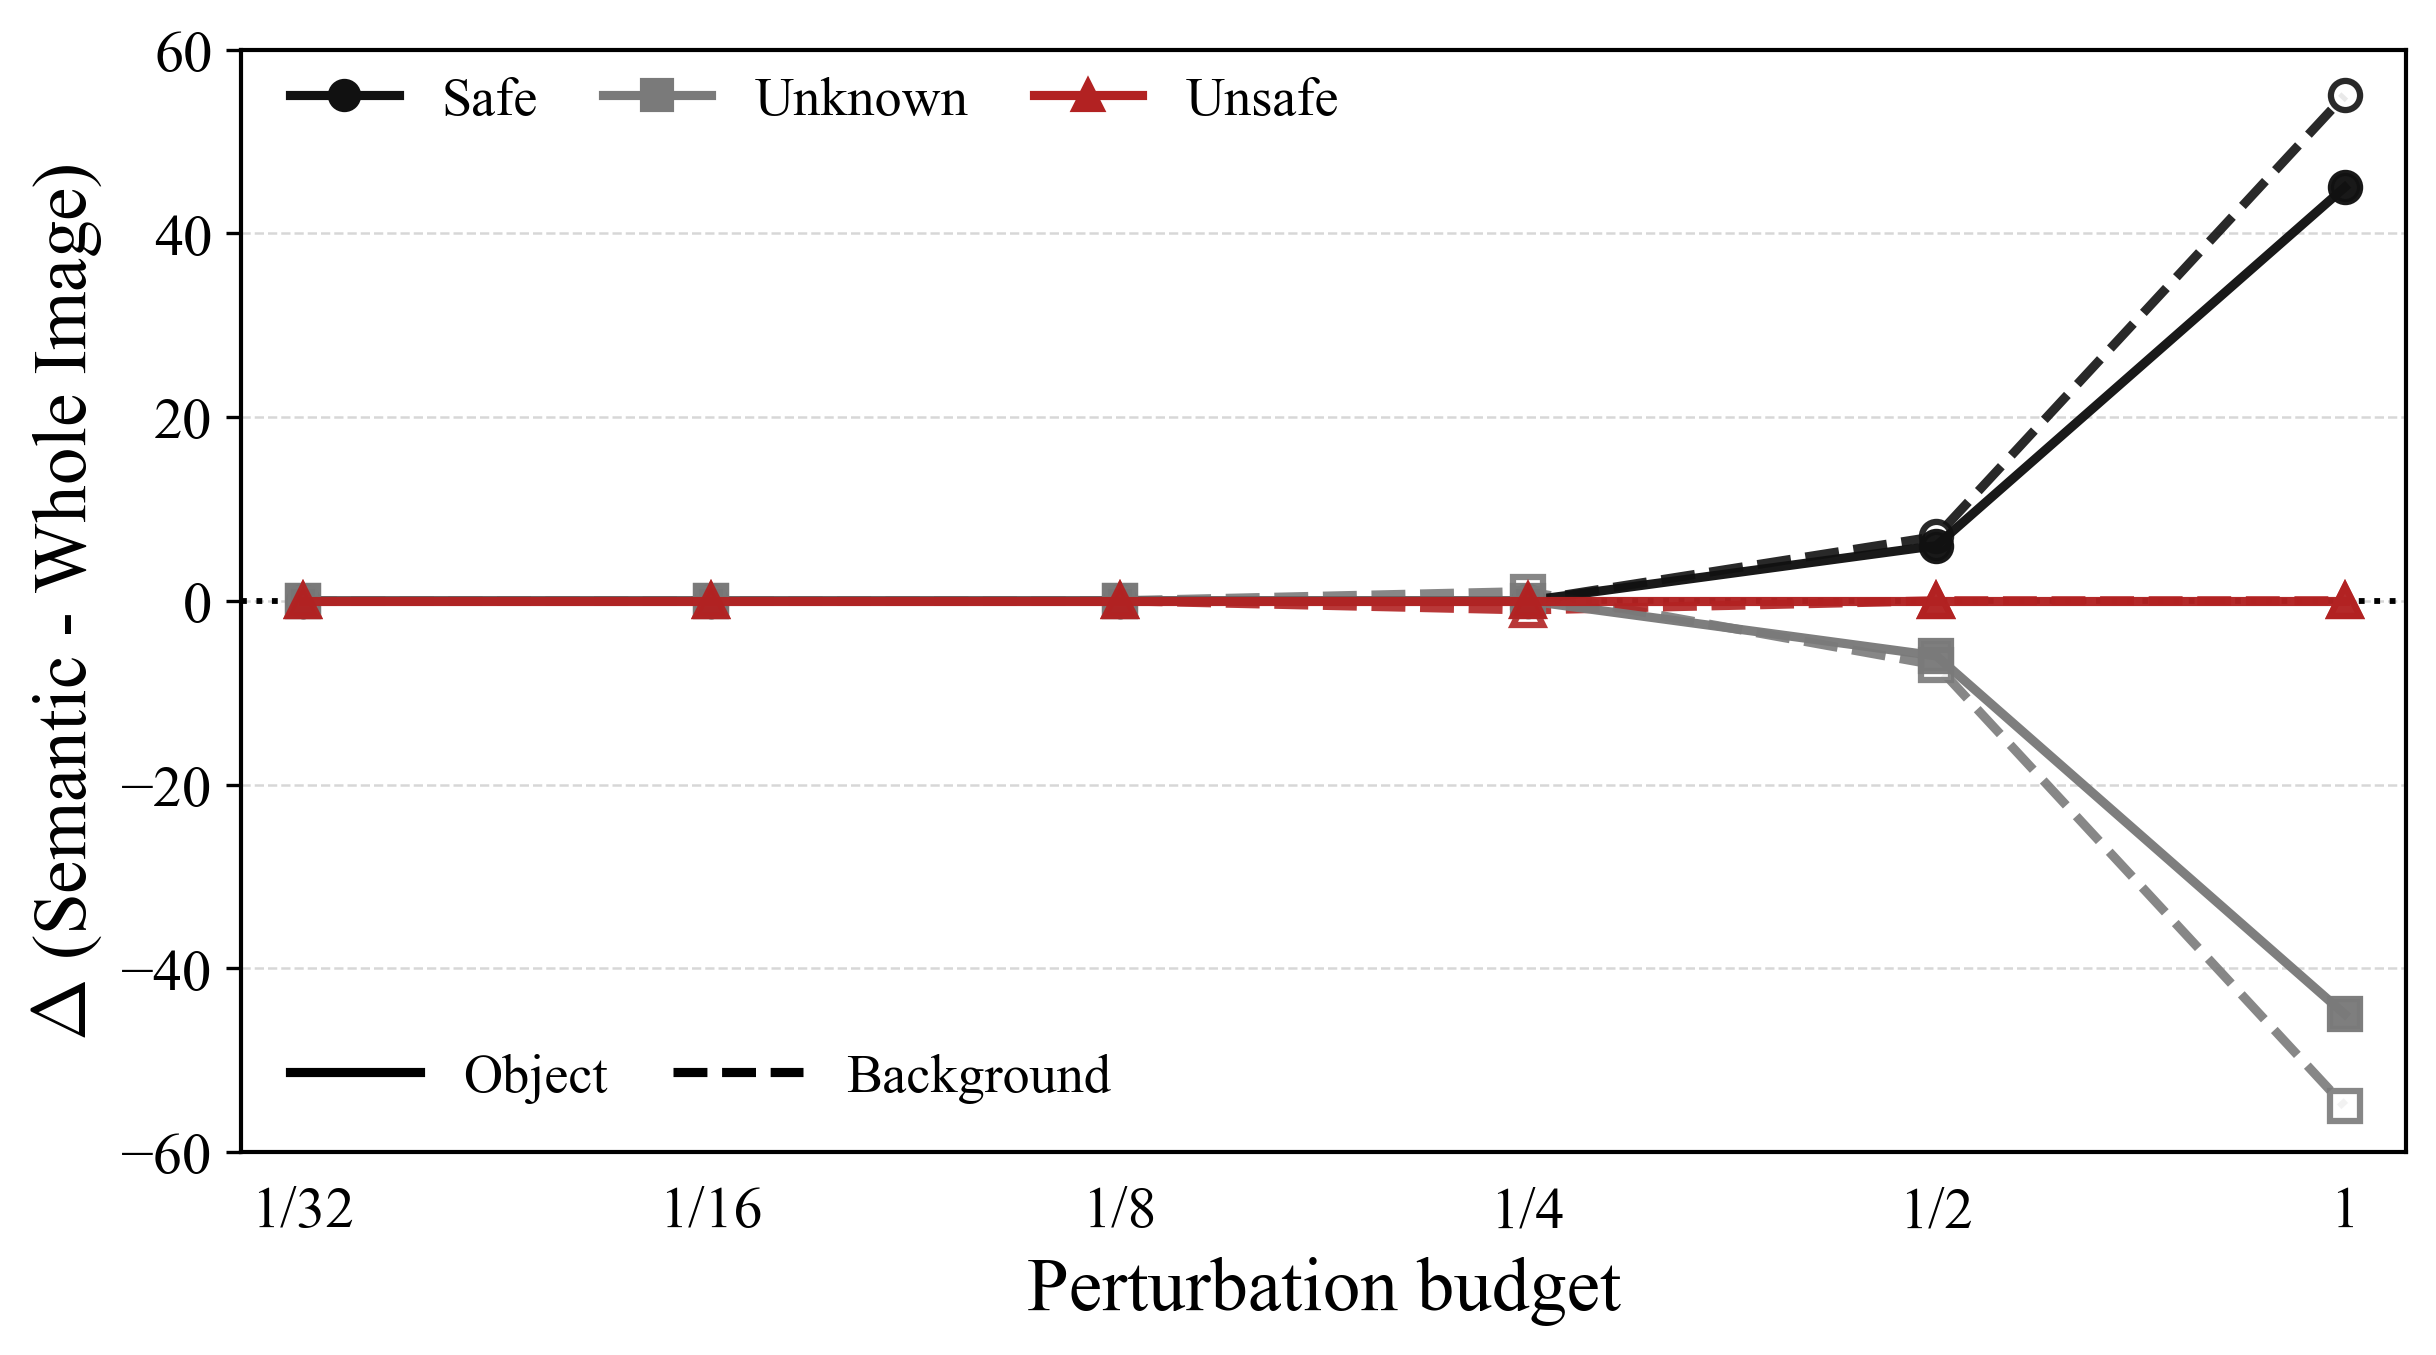

In [4]:
import logging
import os
import shutil
import subprocess
import tempfile
from functools import lru_cache
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
except ImportError:
    set_matplotlib_formats = None

if (Path("plots") / "5.5.1_L0").exists():
    PLOT_DIR = Path("plots") / "5.5.1_L0"
else:
    PLOT_DIR = Path.cwd()

CACHE_ROOT = PLOT_DIR / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

FORCE_TEX = True
BASE_FONT_SIZE = 16
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 14
LEGEND_FONT_SIZE = 13
DEFAULT_FIGSIZE = (8.4, 4.8)

BUDGET_LABELS = ["1/32", "1/16", "1/8", "1/4", "1/2", "1"]
x = np.arange(len(BUDGET_LABELS))

# SERIES = {
#     ("Safe", "Object"):      [0, 0, 0, 0,  2, 28],
#     ("Safe", "Background"):  [0, 0, 0, 0, 11, 72],

#     ("Unknown", "Object"):     [0, 0, 0, 0, -2, -27],
#     ("Unknown", "Background"): [0, 0, 0, 1, -11, -71],

#     ("Unsafe", "Object"):      [0, 0, 0, 0,  0, -1],
#     ("Unsafe", "Background"):  [0, 0, 0, -1, 0, -1],
# }

SERIES = {
    # SAFE (Unknown → Safe transitions)
    ("Safe", "Object"):      [0, 0, 0, 0,  6, 45],
    ("Safe", "Background"):  [0, 0, 0, 0,  7, 55],

    # UNKNOWN (remaining Unknown after transition)
    ("Unknown", "Object"):     [0, 0, 0, 0, -6, -45],
    ("Unknown", "Background"): [0, 0, 0, 1, -7, -55],

    # UNSAFE (only changes when explicitly present)
    ("Unsafe", "Object"):      [0, 0, 0, 0, 0, 0],
    ("Unsafe", "Background"):  [0, 0, 0, -1, 0, 0],
}



OUTCOME_STYLE = {
    "Safe": {"color": "#111111", "marker": "o"},
    "Unknown": {"color": "#7A7A7A", "marker": "s"},
    "Unsafe": {"color": "#B22222", "marker": "^"},
}

REGION_STYLE = {
    "Object": {"linestyle": "-", "linewidth": 2.2, "markerfacecolor": None},
    "Background": {"linestyle": "--", "linewidth": 2.2, "markerfacecolor": "white"},
}

PDF_OUTPUT_PATH = PLOT_DIR / "imagenet_l0_semantic_vs_global_flipped.pdf"
# PNG_OUTPUT_PATH = PLOT_DIR / "imagenet_l0_semantic_vs_global.png"


@lru_cache(maxsize=1)
def latex_ready():
    required_commands = ("latex", "dvipng")
    if any(shutil.which(command) is None for command in required_commands):
        return False

    if shutil.which("kpsewhich") is not None:
        latex_fmt = subprocess.run(
            ["kpsewhich", "latex.fmt"],
            capture_output=True,
            text=True,
            check=False,
        )
        if latex_fmt.returncode != 0 or not latex_fmt.stdout.strip():
            return False

    latex_source = "\n".join([
        r"\documentclass{article}",
        r"\begin{document}",
        r"lp",
        r"\end{document}",
    ])

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_path = Path(tmpdir) / "matplotlib_tex_probe.tex"
        tex_path.write_text(latex_source, encoding="utf-8")
        result = subprocess.run(
            ["latex", "-interaction=nonstopmode", "--halt-on-error", tex_path.name],
            cwd=tmpdir,
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and (Path(tmpdir) / "matplotlib_tex_probe.dvi").exists()


def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0


@lru_cache(maxsize=2)
def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if set_matplotlib_formats is not None:
        if use_tex and shutil.which("dvisvgm") is not None:
            set_matplotlib_formats("svg")
        else:
            set_matplotlib_formats("png")

    if force_tex and not use_tex:
        print(
            "LaTeX was requested but the current environment cannot compile a minimal "
            "TeX document. Falling back to Matplotlib serif text."
        )

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "Times",
            "Nimbus Roman",
            "STIXGeneral",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",
        "text.latex.preamble": preamble,
        "font.size": BASE_FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 1.0,
        "grid.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex


configure_plot_style()

all_values = np.array([value for values in SERIES.values() for value in values], dtype=float)
y_extent = max(1.0, np.max(np.abs(all_values)))
y_padding = max(4.0, np.ceil(0.08 * y_extent))

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE, dpi=300)

for (outcome, region), values in SERIES.items():
    outcome_style = OUTCOME_STYLE[outcome]
    region_style = REGION_STYLE[region]
    markerfacecolor = outcome_style["color"] if region_style["markerfacecolor"] is None else region_style["markerfacecolor"]
    ax.plot(
        x,
        values,
        color=outcome_style["color"],
        marker=outcome_style["marker"],
        markersize=7.0,
        linewidth=region_style["linewidth"],
        linestyle=region_style["linestyle"],
        markerfacecolor=markerfacecolor,
        markeredgecolor=outcome_style["color"],
        markeredgewidth=1.5,
        alpha=0.97 if region == "Object" else 0.9,
        zorder=4 if region == "Object" else 3,
    )

ax.axhline(0, color="black", linewidth=1.4, linestyle=":", zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(BUDGET_LABELS)
ax.set_xlabel(r"Perturbation budget")
ax.set_ylabel(r"$\Delta$ (Semantic - Whole Image)")
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.yaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(axis="x", length=0, pad=8)
ax.margins(x=0.03)
ax.set_ylim(-(y_extent + y_padding), y_extent + y_padding)

outcome_handles = [
    Line2D(
        [0],
        [0],
        color=style["color"],
        marker=style["marker"],
        linestyle="-",
        linewidth=2.2,
        markersize=7.0,
        label=outcome,
    )
    for outcome, style in OUTCOME_STYLE.items()
]

region_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=style["linestyle"],
        linewidth=2.2,
        label=region,
    )
    for region, style in REGION_STYLE.items()
]

outcome_legend = ax.legend(
    handles=outcome_handles,
    frameon=False,
    ncol=3,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.02),
    columnspacing=1.2,
    handlelength=2.0,
)
ax.add_artist(outcome_legend)

ax.legend(
    handles=region_handles,
    frameon=False,
    ncol=2,
    loc="lower left",
    handlelength=2.4,
    columnspacing=1.2,
)

fig.tight_layout()
fig.savefig(PDF_OUTPUT_PATH, bbox_inches="tight")
# fig.savefig(PNG_OUTPUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved: {PDF_OUTPUT_PATH}")

if "agg" in mpl.get_backend().lower():
    plt.close(fig)
else:
    plt.show()
